<a href="https://colab.research.google.com/github/lulwah-mohammed/GP-F31/blob/main/hostcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IoT_Fridge.csv to IoT_Fridge.csv
Saving IoT_Weather.csv to IoT_Weather.csv
Saving IoT_GPS_Tracker.csv to IoT_GPS_Tracker.csv
Saving IoT_Modbus.csv to IoT_Modbus.csv
Saving IoT_Motion_Light.csv to IoT_Motion_Light.csv
Saving IoT_Thermostat.csv to IoT_Thermostat.csv
Saving IoT_Garage_Door(in).csv to IoT_Garage_Door(in).csv


In [ ]:
import os
os.listdir()


['.config',
 'IoT_Garage_Door(in).csv',
 'IoT_GPS_Tracker.csv',
 'IoT_Weather.csv',
 'IoT_Fridge.csv',
 'IoT_Motion_Light.csv',
 'IoT_Thermostat.csv',
 'IoT_Modbus.csv',
 'sample_data']

In [ ]:
import pandas as pd
import os

file_names = [
    'IoT_Fridge.csv',
    'IoT_Garage_Door.csv',
    'IoT_GPS_Tracker.csv',
    'IoT_Modbus.csv',
    'IoT_Motion_Light.csv',
    'IoT_Thermostat.csv'
]

dfs = []

for file in file_names:
    df = pd.read_csv(file)


    device_name = file.replace('IoT_', '').replace('.csv', '')
    df['device_type'] = device_name

    print("=" * 70)
    print(f"File: {file}")
    print(f"Shape: {df.shape}")
    print("Columns:")
    print(df.columns.tolist())
    print("\nFirst 5 rows:")
    display(df.head())

    dfs.append(df)

File: IoT_Fridge.csv
Shape: (587076, 7)
Columns:
['date', 'time', 'fridge_temperature', 'temp_condition', 'label', 'type', 'device_type']

First 5 rows:


,date,time,fridge_temperature,temp_condition,label,type,device_type
0,31-Mar-19,12:36:52,13.10,high,0,normal,Fridge
1,31-Mar-19,12:36:53,8.65,high,0,normal,Fridge
2,31-Mar-19,12:36:54,2.00,low,0,normal,Fridge
3,31-Mar-19,12:36:55,4.80,low,0,normal,Fridge
4,31-Mar-19,12:36:56,10.70,high,0,normal,Fridge


FileNotFoundError: [Errno 2] No such file or directory: 'IoT_Garage_Door.csv'

In [ ]:
import pandas as pd

file_names = [
    'IoT_Fridge.csv',
    'IoT_Weather.csv',
    'IoT_GPS_Tracker.csv',
    'IoT_Modbus.csv',
    'IoT_Motion_Light.csv',
    'IoT_Thermostat.csv',
    'IoT_Garage_Door(in).csv'
]

dfs = []

for file in file_names:
    df = pd.read_csv(file)


    device_name = file.replace('IoT_', '').replace('.csv', '')
    df['device_type'] = device_name

    print(f"{file} -> {df.shape}")

    dfs.append(df)

IoT_Fridge.csv -> (587076, 7)
IoT_Weather.csv -> (650242, 8)
IoT_GPS_Tracker.csv -> (595686, 7)
IoT_Modbus.csv -> (287194, 9)
IoT_Motion_Light.csv -> (452262, 7)
IoT_Thermostat.csv -> (442228, 7)
IoT_Garage_Door(in).csv -> (591446, 7)


/tmp/ipykernel_11979/3166789594.py:16: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


In [ ]:

for i in range(len(dfs)):
    dfs[i] = dfs[i].drop(columns=['date', 'time'], errors='ignore')


combined_df = pd.concat(dfs, ignore_index=True, sort=False)


combined_df = combined_df.fillna(0)

print("Shape after merge:", combined_df.shape)


Shape after merge: (3606134, 20)


In [ ]:
print(combined_df['type'].value_counts())

filtered_df = combined_df[
    combined_df['type'].isin(['normal', 'ransomware'])
]

print(filtered_df['type'].value_counts())

type
normal        3086973
backdoor       246136
password       142674
ddos            53992
injection       50319
ransomware      16030
xss              6037
scanning         3973
Name: count, dtype: int64
type
normal        3086973
ransomware      16030
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

filtered_df['device_type'] = le.fit_transform(filtered_df['device_type'])
filtered_df['type'] = le.fit_transform(filtered_df['type'])

/tmp/ipykernel_11979/937310149.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['device_type'] = le.fit_transform(filtered_df['device_type'])
/tmp/ipykernel_11979/937310149.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['type'] = le.fit_transform(filtered_df['type'])


In [ ]:
X = filtered_df.drop(columns=['type'])
y = filtered_df['type']

In [ ]:
from sklearn.utils import resample

normal = filtered_df[filtered_df['type'] == 0]
attack = filtered_df[filtered_df['type'] == 1]

min_size = min(len(normal), len(attack))

normal_down = resample(normal, replace=False, n_samples=min_size, random_state=42)
attack_down = resample(attack, replace=False, n_samples=min_size, random_state=42)

balanced_df = pd.concat([normal_down, attack_down])

In [ ]:
from sklearn.model_selection import train_test_split

X = balanced_df.drop(columns=['type'])
y = balanced_df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
combined_df['type'].value_counts()

,count
type,
normal,3086973
backdoor,246136
password,142674
ddos,53992
injection,50319
ransomware,16030
xss,6037
scanning,3973


In [ ]:
filtered_df = combined_df[
    combined_df['type'].isin(['normal', 'ransomware'])
]

print(filtered_df['type'].value_counts())

type
normal        3086973
ransomware      16030
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

filtered_df['device_type'] = le.fit_transform(filtered_df['device_type'])
filtered_df['type'] = le.fit_transform(filtered_df['type'])

/tmp/ipykernel_11979/937310149.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['device_type'] = le.fit_transform(filtered_df['device_type'])
/tmp/ipykernel_11979/937310149.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['type'] = le.fit_transform(filtered_df['type'])


In [ ]:
from sklearn.utils import resample

normal = filtered_df[filtered_df['type'] == 0]
ransomware = filtered_df[filtered_df['type'] == 1]

print(len(normal), len(ransomware))  # بس للتأكد

normal_down = resample(
    normal,
    replace=False,
    n_samples=len(ransomware),
    random_state=42
)

balanced_df = pd.concat([normal_down, ransomware])

print(balanced_df['type'].value_counts())

3086973 16030
type
0    16030
1    16030
Name: count, dtype: int64


In [ ]:
X = balanced_df.drop(columns=['type'])
y = balanced_df['type']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred))

ValueError: could not convert string to float: 'low  '

In [ ]:
print(X.dtypes)
print("\nObject columns:")
print(X.select_dtypes(include='object').columns.tolist())

fridge_temperature           float64
temp_condition                object
label                          int64
device_type                    int64
temperature                  float64
pressure                     float64
humidity                     float64
latitude                     float64
longitude                    float64
FC1_Read_Input_Register      float64
FC2_Read_Discrete_Value      float64
FC3_Read_Holding_Register    float64
FC4_Read_Coil                float64
motion_status                float64
light_status                  object
current_temperature          float64
thermostat_status            float64
door_state                    object
sphone_signal                 object
dtype: object

Object columns:
['temp_condition', 'light_status', 'door_state', 'sphone_signal']


In [ ]:
for col in balanced_df.select_dtypes(include='object').columns:
    balanced_df[col] = balanced_df[col].astype(str).str.strip()

In [ ]:
X = balanced_df.drop(columns=['type', 'label'], errors='ignore')
y = balanced_df['type']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

RF Accuracy: 0.7425140361821585

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.63      0.71      3206
           1       0.70      0.86      0.77      3206

    accuracy                           0.74      6412
   macro avg       0.76      0.74      0.74      6412
weighted avg       0.76      0.74      0.74      6412


Confusion Matrix:
 [[2010 1196]
 [ 455 2751]]


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


for col in balanced_df.select_dtypes(include='object').columns:
    balanced_df[col] = balanced_df[col].astype(str).str.strip()


X = balanced_df.drop(columns=['type', 'label'], errors='ignore')
y = balanced_df['type']


X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

RF Accuracy: 0.7425140361821585

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.63      0.71      3206
           1       0.70      0.86      0.77      3206

    accuracy                           0.74      6412
   macro avg       0.76      0.74      0.74      6412
weighted avg       0.76      0.74      0.74      6412


Confusion Matrix:
 [[2010 1196]
 [ 455 2751]]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Random Forest: 0.7425
Decision Tree: 0.7353
SVM: 0.6982
KNN: 0.7381
Naive Bayes: 0.6422
Logistic Regression: 0.6762


In [ ]:
import pandas as pd

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
0,Random Forest,0.742514
3,KNN,0.738147
1,Decision Tree,0.735340
2,SVM,0.698222
5,Logistic Regression,0.676232
4,Naive Bayes,0.642233


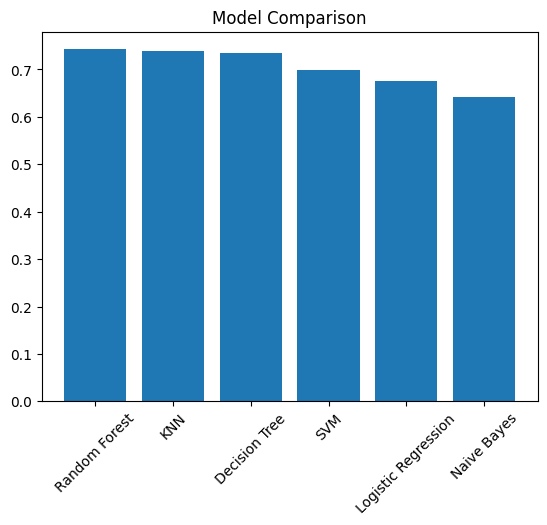

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.show()

In [ ]:

import pandas as pd
import numpy as np

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


file_names = [
    'IoT_Fridge.csv',
    'IoT_Weather.csv',
    'IoT_GPS_Tracker.csv',
    'IoT_Modbus.csv',
    'IoT_Motion_Light.csv',
    'IoT_Thermostat.csv',
    'IoT_Garage_Door(in).csv'
]

dfs = []

for file in file_names:
    df = pd.read_csv(file, low_memory=False)
    device_name = file.replace('IoT_', '').replace('.csv', '')
    df['device_type'] = device_name
    print(f"{file} -> {df.shape}")
    dfs.append(df)

print("\n===== Features in each file =====")
for file, df in zip(file_names, dfs):
    print(f"\n{file}:")
    print(df.columns.tolist())

for i in range(len(dfs)):
    dfs[i] = dfs[i].drop(columns=['date', 'time'], errors='ignore')


combined_df = pd.concat(dfs, ignore_index=True, sort=False)

print("\nCombined shape before fillna:", combined_df.shape)
print("\nCombined columns:")
print(combined_df.columns.tolist())


for col in combined_df.select_dtypes(include='object').columns:
    combined_df[col] = combined_df[col].astype(str).str.strip()


print("\nMissing values before handling:")
print(combined_df.isnull().sum())


for col in combined_df.columns:
    if combined_df[col].dtype == 'object':
        combined_df[col] = combined_df[col].fillna('unknown')
    else:
        combined_df[col] = combined_df[col].fillna(0)

print("\nMissing values after handling:")
print(combined_df.isnull().sum())


print("\nDuplicates before:", combined_df.duplicated().sum())
combined_df = combined_df.drop_duplicates()
print("Duplicates after :", combined_df.duplicated().sum())


print("\nType distribution:")
print(combined_df['type'].value_counts())


filtered_df = combined_df[combined_df['type'].isin(['normal', 'ransomware'])].copy()

print("\nFiltered type distribution:")
print(filtered_df['type'].value_counts())


print("\nFiltered columns:")
print(filtered_df.columns.tolist())

print("\nData types:")
print(filtered_df.dtypes)

X = filtered_df.drop(columns=['type', 'label'], errors='ignore')
y = filtered_df['type']

print("\nFeatures used in X:")
print(X.columns.tolist())

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("\nTarget classes:")
print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


X = pd.get_dummies(X, drop_first=True)

print("\nShape after encoding:", X.shape)

X_temp = X.copy()
X_temp['target'] = y

normal_df = X_temp[X_temp['target'] == 0]
ransomware_df = X_temp[X_temp['target'] == 1]

print("\nBefore balancing:")
print(X_temp['target'].value_counts())

min_size = min(len(normal_df), len(ransomware_df))

normal_down = resample(normal_df, replace=False, n_samples=min_size, random_state=42)
ransomware_down = resample(ransomware_df, replace=False, n_samples=min_size, random_state=42)

balanced_df = pd.concat([normal_down, ransomware_down]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(balanced_df['target'].value_counts())


X_balanced = balanced_df.drop(columns=['target'])
y_balanced = balanced_df['target']


X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}


scaled_models = {"SVM", "KNN", "Naive Bayes", "Logistic Regression"}

results = []


for name, model in models.items():
    print("\n" + "="*60)
    print(f"Model: {name}")

    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n===== Final Comparison =====")
print(results_df)


balanced_df.to_csv("balanced_ransomware_normal_iot.csv", index=False)
print("\nSaved: balanced_ransomware_normal_iot.csv")

IoT_Fridge.csv -> (587076, 7)
IoT_Weather.csv -> (650242, 8)
IoT_GPS_Tracker.csv -> (595686, 7)
IoT_Modbus.csv -> (287194, 9)
IoT_Motion_Light.csv -> (452262, 7)
IoT_Thermostat.csv -> (442228, 7)
IoT_Garage_Door(in).csv -> (591446, 7)

===== Features in each file =====

IoT_Fridge.csv:
['date', 'time', 'fridge_temperature', 'temp_condition', 'label', 'type', 'device_type']

IoT_Weather.csv:
['date', 'time', 'temperature', 'pressure', 'humidity', 'label', 'type', 'device_type']

IoT_GPS_Tracker.csv:
['date', 'time', 'latitude', 'longitude', 'label', 'type', 'device_type']

IoT_Modbus.csv:
['date', 'time', 'FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'label', 'type', 'device_type']

IoT_Motion_Light.csv:
['date', 'time', 'motion_status', 'light_status', 'label', 'type', 'device_type']

IoT_Thermostat.csv:
['date', 'time', 'current_temperature', 'thermostat_status', 'label', 'type', 'device_type']

IoT_Garage_Door(in).csv:
['date', 't

In [ ]:
print("Sample of data:")
display(filtered_df.head(50))

Sample of data:


,fridge_temperature,temp_condition,label,type,device_type,temperature,pressure,humidity,latitude,longitude,FC1_Read_Input_Register,FC2_Read_Discrete_Value,FC3_Read_Holding_Register,FC4_Read_Coil,motion_status,light_status,current_temperature,thermostat_status,door_state,sphone_signal
0,13.10,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
1,8.65,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
2,2.00,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
3,4.80,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
4,10.70,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
5,5.00,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
6,11.65,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
7,3.00,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
9,6.95,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
10,11.95,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan


In [ ]:
empty_cols = filtered_df.columns[filtered_df.isnull().all()]

print("Columns with all NaN:")
print(empty_cols)

Columns with all NaN:
Index([], dtype='object')


In [ ]:
zero_cols = [col for col in filtered_df.columns if (filtered_df[col] == 0).all()]

print("Columns with all zeros:")
print(zero_cols)

Columns with all zeros:
[]


In [ ]:
cols_to_drop = list(empty_cols) + zero_cols

filtered_df = filtered_df.drop(columns=cols_to_drop, errors='ignore')

print("Remaining columns:")
print(filtered_df.columns.tolist())

Remaining columns:
['fridge_temperature', 'temp_condition', 'label', 'type', 'device_type', 'temperature', 'pressure', 'humidity', 'latitude', 'longitude', 'FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'motion_status', 'light_status', 'current_temperature', 'thermostat_status', 'door_state', 'sphone_signal']


In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)

print("Features reduced from", X.shape, "to", X_var.shape)

Features reduced from (1367778, 29) to (1367778, 16)


In [ ]:
filtered_df = combined_df[...]

KeyError: Ellipsis

In [ ]:
filtered_df = combined_df[...]


KeyError: Ellipsis

In [ ]:

filtered_df = combined_df[combined_df['type'].isin(['normal', 'ransomware'])].copy()

print(filtered_df['type'].value_counts())


print("Sample of data:")
display(filtered_df.head(50))


empty_cols = filtered_df.columns[filtered_df.isnull().all()]
print("Columns with all NaN:")
print(list(empty_cols))


zero_cols = []
for col in filtered_df.columns:
    if pd.api.types.is_numeric_dtype(filtered_df[col]):
        if (filtered_df[col] == 0).all():
            zero_cols.append(col)

print("Columns with all zeros:")
print(zero_cols)


cols_to_drop = list(empty_cols) + zero_cols
filtered_df = filtered_df.drop(columns=cols_to_drop, errors='ignore')

print("Remaining columns:")
print(filtered_df.columns.tolist())


type
normal        1359871
ransomware       7907
Name: count, dtype: int64
Sample of data:


,fridge_temperature,temp_condition,label,type,device_type,temperature,pressure,humidity,latitude,longitude,FC1_Read_Input_Register,FC2_Read_Discrete_Value,FC3_Read_Holding_Register,FC4_Read_Coil,motion_status,light_status,current_temperature,thermostat_status,door_state,sphone_signal
0,13.10,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
1,8.65,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
2,2.00,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
3,4.80,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
4,10.70,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
5,5.00,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
6,11.65,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
7,3.00,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
9,6.95,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
10,11.95,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan


Columns with all NaN:
[]
Columns with all zeros:
[]
Remaining columns:
['fridge_temperature', 'temp_condition', 'label', 'type', 'device_type', 'temperature', 'pressure', 'humidity', 'latitude', 'longitude', 'FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'motion_status', 'light_status', 'current_temperature', 'thermostat_status', 'door_state', 'sphone_signal']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from google.colab import files
files.download("balanced_ransomware_normal_iot.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

!pip -q install xgboost catboost


import pandas as pd
import numpy as np

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

file_names = [
    'IoT_Fridge.csv',
    'IoT_Weather.csv',
    'IoT_GPS_Tracker.csv',
    'IoT_Modbus.csv',
    'IoT_Motion_Light.csv',
    'IoT_Thermostat.csv',
    'IoT_Garage_Door(in).csv'
]

dfs = []

for file in file_names:
    df = pd.read_csv(file, low_memory=False)
    device_name = file.replace('IoT_', '').replace('.csv', '')
    df['device_type'] = device_name
    print(f"{file} -> {df.shape}")
    dfs.append(df)


print("\n===== Features in each file =====")
for file, df in zip(file_names, dfs):
    print(f"\n{file}:")
    print(df.columns.tolist())


for i in range(len(dfs)):
    dfs[i] = dfs[i].drop(columns=['date', 'time'], errors='ignore')


combined_df = pd.concat(dfs, ignore_index=True, sort=False)

print("\nCombined shape before missing-value handling:", combined_df.shape)
print("\nCombined columns:")
print(combined_df.columns.tolist())


for col in combined_df.select_dtypes(include='object').columns:
    combined_df[col] = combined_df[col].astype(str).str.strip()


print("\nMissing values before handling:")
print(combined_df.isnull().sum())

for col in combined_df.columns:
    if combined_df[col].dtype == 'object':
        combined_df[col] = combined_df[col].fillna('unknown')
    else:
        combined_df[col] = combined_df[col].fillna(0)

print("\nMissing values after handling:")
print(combined_df.isnull().sum())


print("\nDuplicates before:", combined_df.duplicated().sum())
combined_df = combined_df.drop_duplicates()
print("Duplicates after :", combined_df.duplicated().sum())


print("\nOriginal class distribution:")
print(combined_df['type'].value_counts())

filtered_df = combined_df[combined_df['type'].isin(['normal', 'ransomware'])].copy()

print("\nFiltered class distribution:")
print(filtered_df['type'].value_counts())


print("\nSample of filtered data:")
display(filtered_df.head(50))


empty_cols = filtered_df.columns[filtered_df.isnull().all()]
print("\nColumns with all NaN:")
print(list(empty_cols))

zero_cols = []
for col in filtered_df.columns:
    if pd.api.types.is_numeric_dtype(filtered_df[col]):
        if (filtered_df[col] == 0).all():
            zero_cols.append(col)

print("\nColumns with all zeros:")
print(zero_cols)

cols_to_drop = list(empty_cols) + zero_cols
filtered_df = filtered_df.drop(columns=cols_to_drop, errors='ignore')

print("\nRemaining columns:")
print(filtered_df.columns.tolist())


X = filtered_df.drop(columns=['type', 'label'], errors='ignore')
y = filtered_df['type']

print("\nFeatures used in X:")
print(X.columns.tolist())


target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("\nTarget mapping:")
print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


X = pd.get_dummies(X, drop_first=True)

print("\nShape after feature encoding:", X.shape)


temp_df = X.copy()
temp_df['target'] = y

normal_df = temp_df[temp_df['target'] == 0]
ransomware_df = temp_df[temp_df['target'] == 1]

print("\nBefore balancing:")
print(temp_df['target'].value_counts())

min_size = min(len(normal_df), len(ransomware_df))

normal_down = resample(
    normal_df,
    replace=False,
    n_samples=min_size,
    random_state=42
)

ransomware_down = resample(
    ransomware_df,
    replace=False,
    n_samples=min_size,
    random_state=42
)

balanced_df = pd.concat([normal_down, ransomware_down])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(balanced_df['target'].value_counts())


X_balanced = balanced_df.drop(columns=['target'])
y_balanced = balanced_df['target']


X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        verbose=0,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

scaled_models = {"Logistic Regression", "KNN"}


results = []
predictions = {}

for name, model in models.items():
    print("\n" + "="*70)
    print(f"Model: {name}")

    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(cm)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    })


results_df = pd.DataFrame(results).sort_values(
    by=["Accuracy", "F1-score"],
    ascending=False
).reset_index(drop=True)

print("\n===== Final Model Comparison =====")
display(results_df)


results_df.to_csv("model_results_comparison.csv", index=False)
balanced_df.to_csv("balanced_ransomware_normal_iot.csv", index=False)

print("\nSaved files:")
print("- model_results_comparison.csv")
print("- balanced_ransomware_normal_iot.csv")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00
IoT_Fridge.csv -> (587076, 7)
IoT_Weather.csv -> (650242, 8)
IoT_GPS_Tracker.csv -> (595686, 7)
IoT_Modbus.csv -> (287194, 9)
IoT_Motion_Light.csv -> (452262, 7)
IoT_Thermostat.csv -> (442228, 7)
IoT_Garage_Door(in).csv -> (591446, 7)

===== Features in each file =====

IoT_Fridge.csv:
['date', 'time', 'fridge_temperature', 'temp_condition', 'label', 'type', 'device_type']

IoT_Weather.csv:
['date', 'time', 'temperature', 'pressure', 'humidity', 'label', 'type', 'device_type']

IoT_GPS_Tracker.csv:
['date', 'time', 'latitude', 'longitude', 'label', 'type', 'device_type']

IoT_Modbus.csv:
['date', 'time', 'FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'label', 'type', 'device_type']

IoT_Motion_Light.csv:
['date', 'time', 'motion_status', 'light_status', 'label', 'type', 'device_type']

IoT_Thermostat.csv:
['date', 'time', 'current_temperature', 'thermostat_

,fridge_temperature,temp_condition,label,type,device_type,temperature,pressure,humidity,latitude,longitude,FC1_Read_Input_Register,FC2_Read_Discrete_Value,FC3_Read_Holding_Register,FC4_Read_Coil,motion_status,light_status,current_temperature,thermostat_status,door_state,sphone_signal
0,13.10,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
1,8.65,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
2,2.00,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
3,4.80,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
4,10.70,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
5,5.00,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
6,11.65,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
7,3.00,low,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
9,6.95,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan
10,11.95,high,0,normal,Fridge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,nan,nan



Columns with all NaN:
[]

Columns with all zeros:
[]

Remaining columns:
['fridge_temperature', 'temp_condition', 'label', 'type', 'device_type', 'temperature', 'pressure', 'humidity', 'latitude', 'longitude', 'FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'motion_status', 'light_status', 'current_temperature', 'thermostat_status', 'door_state', 'sphone_signal']

Features used in X:
['fridge_temperature', 'temp_condition', 'device_type', 'temperature', 'pressure', 'humidity', 'latitude', 'longitude', 'FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'motion_status', 'light_status', 'current_temperature', 'thermostat_status', 'door_state', 'sphone_signal']

Target mapping:
{'normal': np.int64(0), 'ransomware': np.int64(1)}

Shape after feature encoding: (1367778, 29)

Before balancing:
target
0    1359871
1       7907
Name: count, dtype: int64

After balancing:
target
1    7907
0    7

,Model,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,Random Forest,0.817894,0.810761,0.829222,0.819887,1276,306,270,1311
1,XGBoost,0.816630,0.784214,0.873498,0.826451,1202,380,200,1381
2,KNN,0.813152,0.791519,0.850095,0.819762,1228,354,237,1344
3,CatBoost,0.812836,0.757955,0.919039,0.830760,1118,464,128,1453
4,Logistic Regression,0.716725,0.648461,0.946237,0.769547,771,811,85,1496



Saved files:
- model_results_comparison.csv
- balanced_ransomware_normal_iot.csv


In [ ]:
from google.colab import files

files.download("model_results_comparison.csv")
files.download("balanced_ransomware_normal_iot.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Type of IDS,Model Used,Results
0,Host-Based (IoT Telemetry),Random Forest,"Accuracy: 81.79%, Recall: 83%, F1-score: 82%"
1,Host-Based (IoT Telemetry),XGBoost,"Accuracy: 81.66%, Recall: 87%, F1-score: 83%"
2,Host-Based (IoT Telemetry),CatBoost,"Accuracy: 81.28%, Recall: 91%, F1-score: 83%"
3,Host-Based (IoT Telemetry),Logistic Regression,"Accuracy: 71.67%, Recall: 94%, F1-score: 77%"
4,Host-Based (IoT Telemetry),KNN,"Accuracy: 81.32%, Recall: 85%, F1-score: 82%"


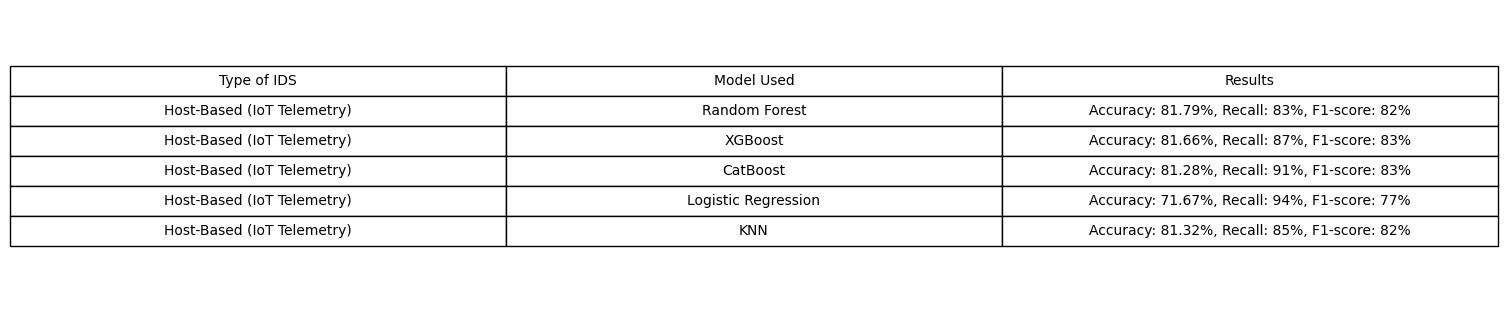

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Type of IDS": [
        "Host-Based (IoT Telemetry)",
        "Host-Based (IoT Telemetry)",
        "Host-Based (IoT Telemetry)",
        "Host-Based (IoT Telemetry)",
        "Host-Based (IoT Telemetry)"
    ],
    "Model Used": [
        "Random Forest",
        "XGBoost",
        "CatBoost",
        "Logistic Regression",
        "KNN"
    ],
    "Results": [
        "Accuracy: 81.79%, Recall: 83%, F1-score: 82%",
        "Accuracy: 81.66%, Recall: 87%, F1-score: 83%",
        "Accuracy: 81.28%, Recall: 91%, F1-score: 83%",
        "Accuracy: 71.67%, Recall: 94%, F1-score: 77%",
        "Accuracy: 81.32%, Recall: 85%, F1-score: 82%"
    ]
})
display(results_df)


fig, ax = plt.subplots(figsize=(16, 3.8))
ax.axis('off')

table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

plt.savefig("ids_models_results.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("ids_models_results.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>